In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
# Configuration and paths
mac = 20
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

abs_phenotypes = False

# ============================================================
# Variant class selection — change this to switch variant class
# Available: missense, missense_structured, missense_non_structured,
#   missense_disordered, missense_lip, intron,
#   enhancer_encode, promoter_encode, tf_encode, core_promoter
# ============================================================
variant_class = 'all_variants'
exclude_clinvar = False  # Independent toggle: exclude ClinVar-annotated variants

# Load variant class configuration
variant_class_path = "/home/dnanexus/ukbgym/config_variant_classes.yaml"
with open(variant_class_path) as f:
    variant_class_config = yaml.safe_load(f)

vc = variant_class_config[variant_class]
vc_filters = vc['variant_filtering']

print(f"Variant class: {variant_class}")
print(f"  Filters: {vc_filters}")
print(f"  Exclude ClinVar: {exclude_clinvar}")

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_pheno.yaml" 

with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

Variant class: all_variants
  Filters: None
  Exclude ClinVar: False


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1


In [4]:
# Subset Olink RVAT significant
LOCAL_DATA_DIR = "/home/dnanexus/data_dir/"

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o {LOCAL_DATA_DIR}/{olink_burden_test_file}

olink_whitelist = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
olink_correlations_file = "olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o {LOCAL_DATA_DIR}/{olink_correlations_file}

olink_corrs = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_correlations_file}')
    .filter(pl.col('correlation')>0)
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir//proteomics_prs_df_loftee_mac20_burden_re
gression_results.parquet" already exists but -f/--overwrite was not set
[===========================================================>] Completed 21,491 of 21,491 bytes (100%) /home/dnanexus/data_dir//olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquett


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000116675""","""ENSG00000116675_olink""",0.022487,0.022487,1.0
"""ENSG00000123609""","""ENSG00000123609_olink""",0.076186,0.076186,1.0
"""ENSG00000167851""","""ENSG00000167851_olink""",0.066067,0.066067,1.0
"""ENSG00000156711""","""ENSG00000156711_olink""",0.04852,0.04852,1.0
"""ENSG00000174990""","""ENSG00000174990_olink""",0.010786,0.010786,1.0
…,…,…,…,…
"""ENSG00000136542""","""ENSG00000136542_olink""",0.040315,0.040315,1.0
"""ENSG00000196576""","""ENSG00000196576_olink""",0.082542,0.082542,1.0
"""ENSG00000111144""","""ENSG00000111144_olink""",0.088107,0.088107,1.0


In [5]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_all_260218_0_ukbbgym.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = (
    pl.scan_parquet(new_anno_local)
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .with_columns(
        fz_blood_min = pl.min_horizontal(pl.col(['RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533'])),
        fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
    )
    .select(['id', 'region', 'fz_blood_min', 'fz_all_min'])
    .collect()
)

new_anno_df

Error: path "/home/dnanexus/data_dir/ukbbgym_TSS_promoter_enhancer_TF_variants
_all_260218_0_ukbbgym.parquet" already exists but -f/--overwrite was not set


/tmp/ipykernel_267682/2692276253.py:15: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,fz_blood_min,fz_all_min
str,str,f32,f32
"""chr20:44726245:G:A""","""ENSG00000064205""",-0.001006,-0.006898
"""chr7:8251452:T:C""","""ENSG00000003147""",-0.000939,-0.013746
"""chr12:10309195:A:G""","""ENSG00000134539""",0.002081,-0.01001
"""chr2:162198524:G:A""","""ENSG00000078098""",0.00508,-0.002404
"""chr12:132769639:G:C""","""ENSG00000090615""",-0.002022,-0.004555
…,…,…,…
"""chr17:1645491:A:C""","""ENSG00000074660""",-0.017778,-0.033511
"""chr12:56007826:G:T""","""ENSG00000139531""",-0.004501,-0.021009
"""chr6:159982939:G:A""","""ENSG00000197081""",-0.008397,-0.008397


In [7]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

# Build dynamic filters from variant_class.yaml
if vc_filters is not None:
    _dynamic_filters = [eval(f) for f in vc_filters]
else:
    _dynamic_filters = []

anno = (
    anno
    .filter(
        # Always-applied filters
        (pl.col('region').is_in(olink_whitelist['region'].unique())),
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1),

        # Dynamic filters from variant_class.yaml + exclude_clinvar
        *_dynamic_filters,
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
        promoterai_under = pl.col('promoterai'),
    )
)

selected_categories = ['plof', 'missense', 'splicing', 'conservation', 'regulatory'] # Gene Body
# selected_categories = ['missense'] # missense
# selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['loftee_protein_domains'] # protein domains
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['genetic_diversity', 'conservation', 'naive']    # plof comparison
# selected_categories = ['genetic_diversity', 'splicing', 'conservation', 'regulatory', 'regulatory_nondir'] # non coding
# selected_categories = ['genetic_diversity', 'splicing', 'conservation'] # introns

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_267682/298417723.py:56: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_267682/298417723.py:65: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


esm1b_llr,region,abexp_min,gpn_score,esmscoremissense,verphylop,polyphen,revel_score,delta_score,fz_all_min,bayes_del,promoterai_abs,pangolin_score,clinpred_score,promoterai_under,cpt1_llr,loftee_hc,am_pathogenicity,id,absplice2_max
f32,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i8,f32,str,f32
0.0,"""ENSG00000111452""",-0.004254,0.72,0.0,-0.008,0.0,0.0,0.0,-0.000358,-0.249576,0.0,0.0,0.0,0.0,0.0,0,0.0,"""chr12:131103985:A:G""",0.000141
0.0,"""ENSG00000067208""",-0.006286,1.91,0.0,0.203,0.0,0.0,0.0,null,-0.249576,0.0,0.0,0.0,0.0,0.0,0,0.0,"""chr1:92563948:C:T""",0.000033
0.0,"""ENSG00000090615""",0.002469,-1.54,0.0,-0.056,0.0,0.0,0.0,null,-0.249576,0.0,0.0,0.0,0.0,0.0,0,0.0,"""chr12:132832209:G:A""",0.0
0.0,"""ENSG00000174175""",-0.006261,-1.33,0.0,-0.808,0.0,0.0,0.0,null,-0.249576,0.0,0.0,0.0,0.0,0.0,0,0.0,"""chr1:169623948:T:G""",0.000033
0.0,"""ENSG00000168522""",-0.006189,0.65,0.0,-0.294,0.0,0.0,0.0,null,-0.249576,0.0,0.0,0.0,0.0,0.0,0,0.0,"""chr8:43067079:C:T""",0.000033
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-3.51,"""ENSG00000138615""",-0.073285,-5.5,-3.459,4.275,0.007,0.016,0.0,null,-0.476029,0.0,0.0,0.598302,0.0,0.080439,0,0.079,"""chr15:65207723:G:T""",0.000296
0.0,"""ENSG00000115598""",0.0,-1.22,0.0,-1.167,0.0,0.0,0.0,-0.014045,-0.249576,0.0,0.0,0.0,0.0,0.0,0,0.0,"""chr2:102185622:A:T""",0.0
0.0,"""ENSG00000069702""",-0.005501,0.24,0.0,0.146,0.0,0.0,0.0,-0.003781,-0.249576,0.0,0.0,0.0,0.0,0.0,0,0.0,"""chr1:91778000:A:G""",0.000033


In [8]:
melted_anno = (
    anno

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    ).with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr12:131103985:A:G""","""ENSG00000111452""","""esm1b_llr""",0.0
"""chr1:92563948:C:T""","""ENSG00000067208""","""esm1b_llr""",0.0
"""chr12:132832209:G:A""","""ENSG00000090615""","""esm1b_llr""",0.0
"""chr1:169623948:T:G""","""ENSG00000174175""","""esm1b_llr""",0.0
"""chr8:43067079:C:T""","""ENSG00000168522""","""esm1b_llr""",0.0
…,…,…,…
"""chr15:65207723:G:T""","""ENSG00000138615""","""delta_score""",0.0
"""chr2:102185622:A:T""","""ENSG00000115598""","""delta_score""",0.0
"""chr1:91778000:A:G""","""ENSG00000069702""","""delta_score""",0.0


In [9]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Small APPV file has no 'region' column — region is added via id_region join in the computation cell
olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(-pl.col('mean_pheno_value')) # Descending for olink
    )
    .select(['id', 'phenotype', 'mean_pheno_value', 'n_individuals'])
)

[===========================================================>] Completed 100,324,032 of 100,324,032 bytes (100%) /home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquett


In [10]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Join order: appv → id_region (adds region) → olink_whitelist (filter early) → melted_anno (annotation scores)
final_lazy_plan = (
    olink_appv
    .join(id_region, on='id', how='inner')
    .join(
        olink_whitelist[["region", "phenotype"]].lazy(),
        on=["region", "phenotype"],
        how="inner"
    )
    .join(
        melted_anno.lazy(),
        on=["id", "region"],
        how="inner"
    )

    # Spearman: rank with "average" for proper tie handling
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['mean_pheno_value', 'annotation_score']
    )
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None)
    )

    .select(['region', 'phenotype', 'annotation', 'n_variants', 'correlation'])

    .drop_nans().drop_nulls()

    .collect(engine='streaming')
)

# Join with beta directions and annotation directions
correlation_df = (
    final_lazy_plan

    .join(
        anno_config_df,
        on='annotation'
    )
    .join(
        olink_whitelist,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

correlation_df

region,phenotype,annotation,n_variants,correlation,category,color,label,annotation_dir,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,str,i8,f64,f64,f64,f64,f64
"""ENSG00000130038""","""ENSG00000130038_olink""","""verphylop""",6893,0.006568,"""conservation""","""#942c80""","""Vertebrate PhyloP""",1,0.023537,0.023537,1.0,0.006568,0.279052
"""ENSG00000103024""","""ENSG00000103024_olink""","""absplice2_max""",1015,0.187292,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.052517,0.052517,1.0,0.187292,3.566283
"""ENSG00000229314""","""ENSG00000229314_olink""","""gpn_score""",687,-0.069305,"""conservation""","""#942c80""","""GPN-MSA""",-1,0.092773,0.092773,1.0,0.069305,0.747035
"""ENSG00000163534""","""ENSG00000163534_olink""","""verphylop""",1983,0.019624,"""conservation""","""#942c80""","""Vertebrate PhyloP""",1,0.038572,0.038572,1.0,0.019624,0.508771
"""ENSG00000164054""","""ENSG00000164054_olink""","""clinpred_score""",2210,0.054463,"""missense""","""#feb72d""","""ClinPred""",1,0.036735,0.036735,1.0,0.054463,1.482577
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000107201""","""ENSG00000107201_olink""","""bayes_del""",4132,0.048898,"""missense""","""#feb72d""","""BayesDel""",1,0.048227,0.048227,1.0,0.048898,1.013906
"""ENSG00000118113""","""ENSG00000118113_olink""","""clinpred_score""",1285,0.062364,"""missense""","""#feb72d""","""ClinPred""",1,0.13866,0.13866,1.0,0.062364,0.449762
"""ENSG00000187838""","""ENSG00000187838_olink""","""verphylop""",693,0.13882,"""conservation""","""#942c80""","""Vertebrate PhyloP""",1,0.08135,0.08135,1.0,0.13882,1.706447


In [11]:
(
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['annotation'])
    .agg(n_regions = pl.len())
    .sort('n_regions', descending=True)
)

annotation,n_regions
str,u64
"""verphylop""",1076
"""loftee_hc""",1076
"""promoterai_under""",1076
"""promoterai_abs""",1076
"""gpn_score""",1076
…,…
"""absplice2_max""",1049
"""polyphen""",1048
"""delta_score""",1047


In [12]:
consistent_genes = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    # .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_genes, on=['region'], how='inner')
filt_corr_df.sort('corr_beta', descending=True)

region,phenotype,annotation,n_variants,correlation,category,color,label,annotation_dir,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,str,str,str,i8,f64,f64,f64,f64,f64,u64
"""ENSG00000131471""","""ENSG00000131471_olink""","""polyphen""",1094,0.31485,"""missense""","""#feb72d""","""PolyPhen2""",1,0.16163,0.16163,1.0,0.31485,1.947968,18
"""ENSG00000131471""","""ENSG00000131471_olink""","""cpt1_llr""",1094,0.312514,"""missense""","""#feb72d""","""CPT-1""",1,0.16163,0.16163,1.0,0.312514,1.933516,18
"""ENSG00000131471""","""ENSG00000131471_olink""","""am_pathogenicity""",1094,0.311126,"""missense""","""#feb72d""","""AlphaMissense""",1,0.16163,0.16163,1.0,0.311126,1.924932,18
"""ENSG00000131471""","""ENSG00000131471_olink""","""revel_score""",1094,0.310627,"""missense""","""#feb72d""","""REVEL""",1,0.16163,0.16163,1.0,0.310627,1.921843,18
"""ENSG00000131471""","""ENSG00000131471_olink""","""esmscoremissense""",1094,-0.308919,"""missense""","""#feb72d""","""ESM1v""",-1,0.16163,0.16163,1.0,0.308919,1.911273,18
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000079689""","""ENSG00000079689_olink""","""fz_all_min""",2758,0.111739,"""regulatory""","""#1f77b4""","""Flashzoi min across RNA (all)""",-1,0.039875,0.039875,1.0,-0.111739,-2.802231,18
"""ENSG00000163295""","""ENSG00000163295_olink""","""fz_all_min""",722,0.113725,"""regulatory""","""#1f77b4""","""Flashzoi min across RNA (all)""",-1,0.101794,0.101794,1.0,-0.113725,-1.117205,18
"""ENSG00000134809""","""ENSG00000134809_olink""","""fz_all_min""",550,0.140421,"""regulatory""","""#1f77b4""","""Flashzoi min across RNA (all)""",-1,0.071906,0.071906,1.0,-0.140421,-1.952834,18


In [13]:
# Filter to only those with sign agreement
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 10
Inconsistent (region, phenotype) pairs: 0


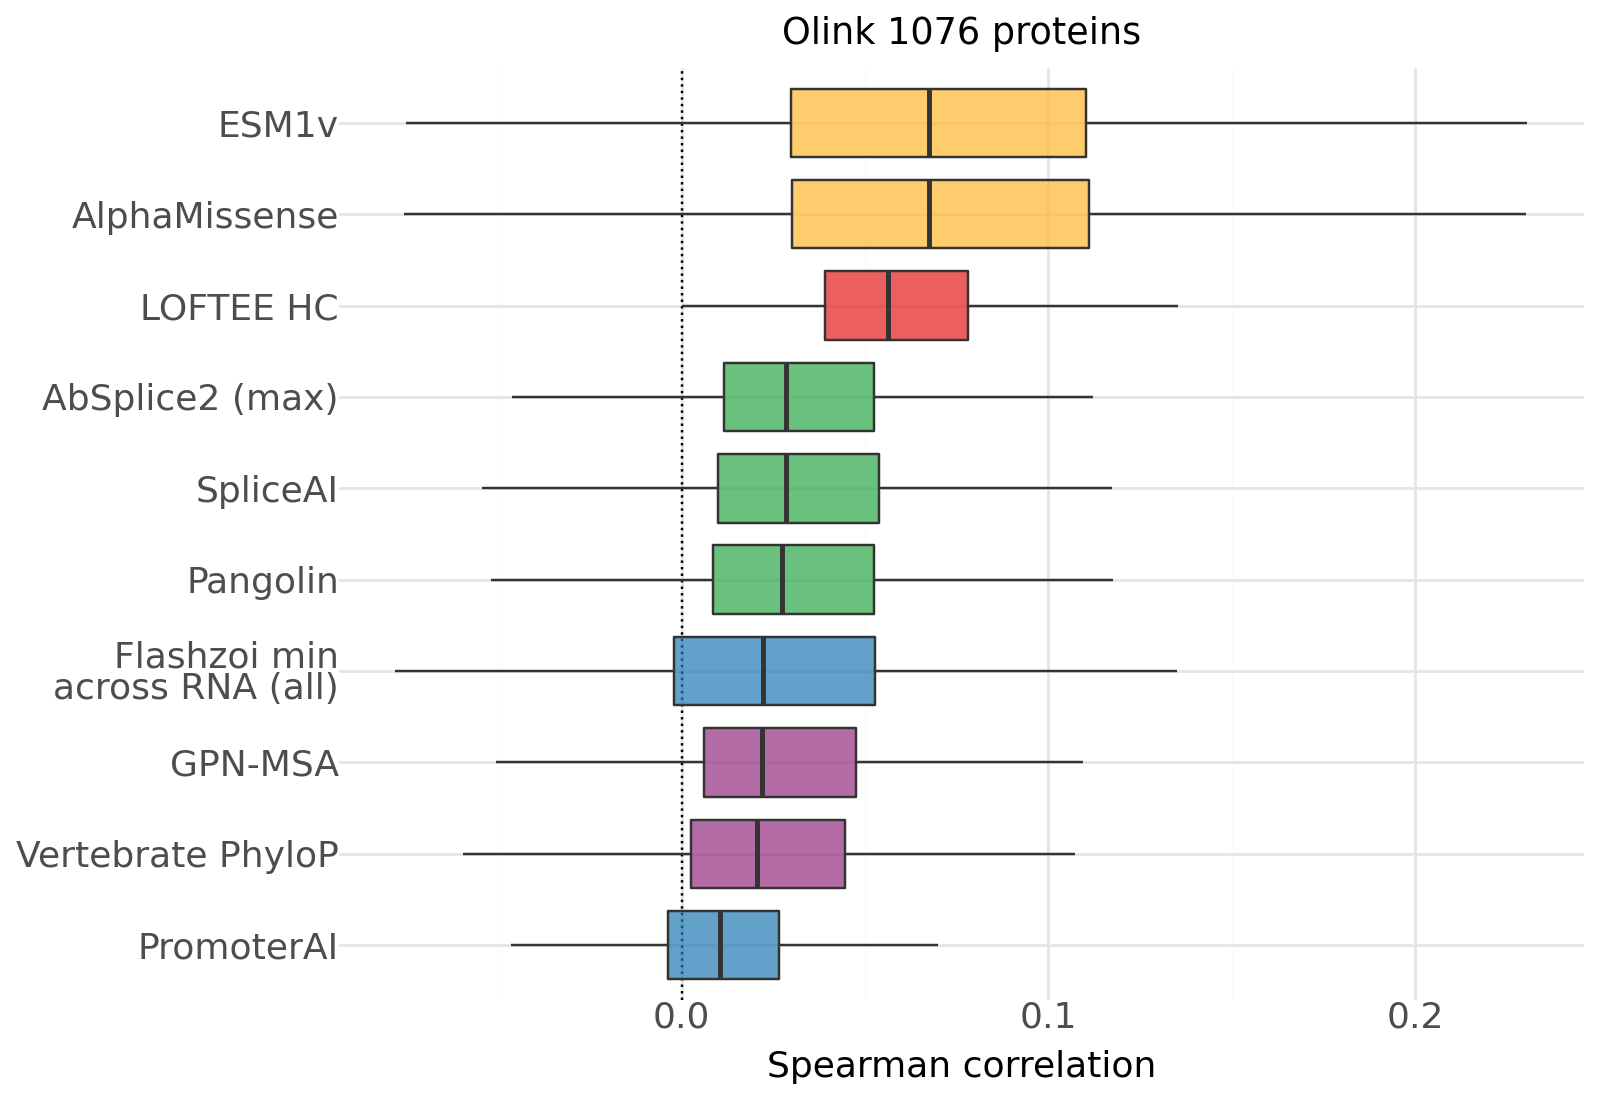

In [16]:
plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

models2plot = ['loftee_hc', 'am_pathogenicity', 'esmscoremissense', 'pangolin_score', 'delta_score', 'absplice2_max', 'gpn_score', 'verphylop', 'fz_all_min', 'promoterai_under']

# Calculate medians and join back
corr_pl = (
    filt_corr_df
    .drop_nans()
    .filter(pl.col('annotation').is_in(models2plot))
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
corr_pl = corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

# 4. Create the color dictionary (Polars style)
color_dict = dict(corr_pl.select("annotation", "color").unique().iter_rows())

# Plot
(
    ggplot(corr_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    # + geom_boxplot(alpha=0.7)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"Olink {len(corr_pl['region'].unique())} proteins"
            # \nmissense variants"
            # \nGene body ±5kb"
            # \nTSS [{min_range}bp, {max_range}bp]"
            # \nsplice donor/acceptor variants"
    )
    + coord_flip()
    + theme(
        figure_size=(8, corr_pl['annotation'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [15]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "corr_beta"])

    merged = df_a.join(df_b, on=["region"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_267682/863415217.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""promoterai_abs""","""loftee_hc""",1076,11377.0,4.4175e-164
"""loftee_hc""","""promoterai_under""",1076,14898.0,5.2348e-160
"""promoterai_abs""","""esmscoremissense""",1076,32824.0,4.5393e-140
"""promoterai_abs""","""revel_score""",1059,31242.0,1.7065e-138
"""promoterai_abs""","""esm1b_llr""",1054,31830.0,6.9930e-137
…,…,…,…,…
"""revel_score""","""cpt1_llr""",1015,233476.0,0.009191
"""polyphen""","""esmscoremissense""",1048,249817.0,0.010681
"""am_pathogenicity""","""polyphen""",1016,236852.0,0.021764


# Stratify by LOEUF score

In [13]:
gnom = (
    pl.read_csv(
        "/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv", 
        null_values=["NA"],
        separator='\t'
    )
    .filter(
        pl.col('transcript_type')=='protein_coding',
        pl.col('canonical')==True
        # pl.col('mane_select')==True
    )
    .select(['gene_id', 'lof.oe_ci.upper'])
    .rename({'gene_id': 'region', 'lof.oe_ci.upper': 'loeuf'})
    .drop_nulls()
)

gnom

region,loeuf
str,f64
"""ENSG00000121410""",1.34
"""ENSG00000148584""",0.825
"""ENSG00000175899""",0.765
"""ENSG00000166535""",0.953
"""ENSG00000184389""",1.529
…,…
"""ENSG00000288914""",1.87
"""ENSG00000289027""",0.885
"""ENSG00000289258""",0.982


In [14]:
set(correlation_df['region'].unique()) - set(gnom['region'].unique())

set()

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 20'. Pick better value with 'binwidth'.


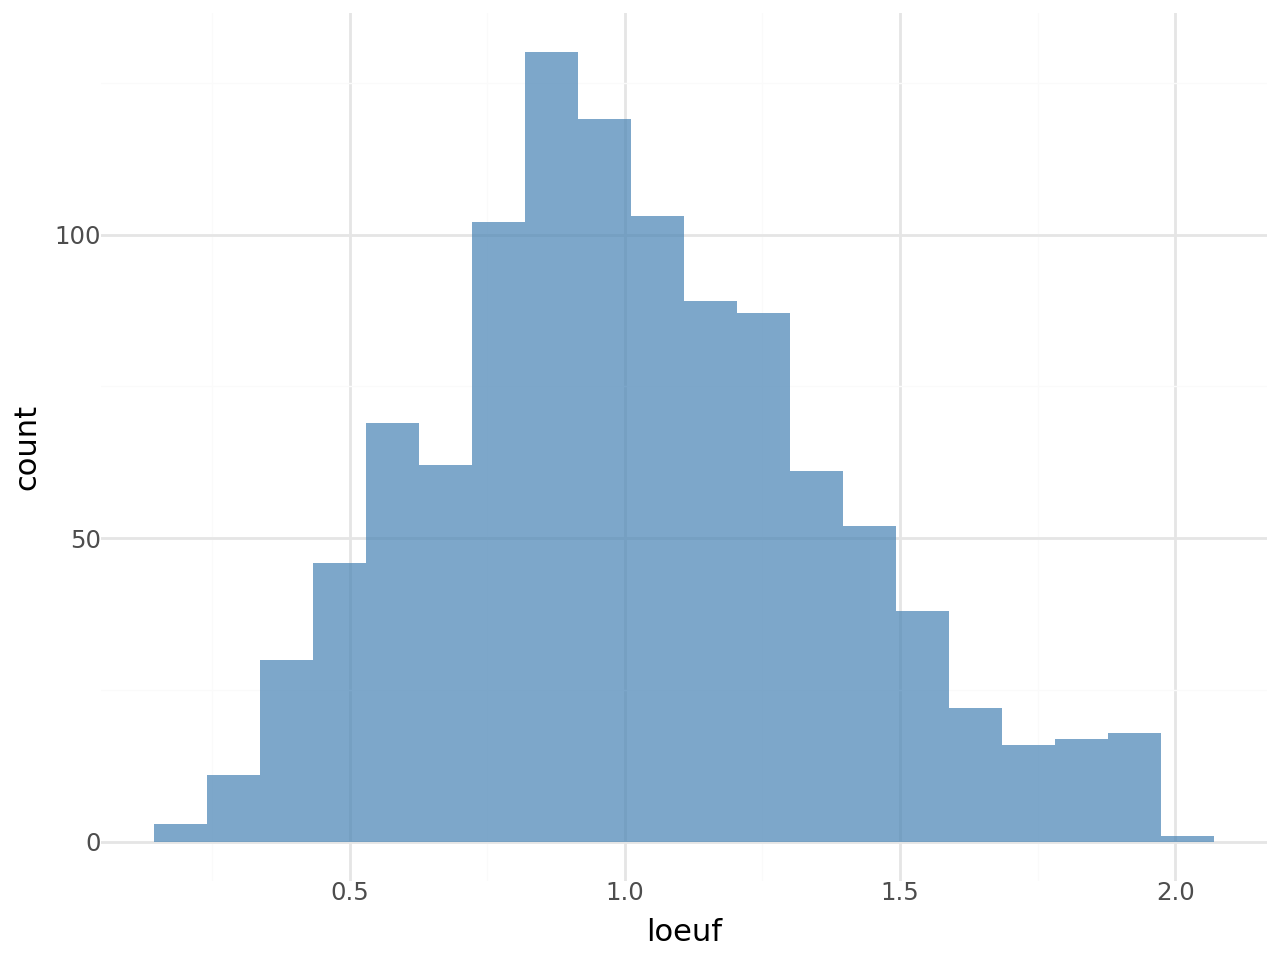

In [15]:
tmp = gnom.join(correlation_df.select(['region']).unique(), on='region', how='inner').with_columns(subset=pl.lit('ukbbgym_pheno'))

(
    ggplot(tmp, aes(x='loeuf'))
    + geom_histogram(position='identity', fill='steelblue', alpha=0.7)
    + theme_minimal()
)

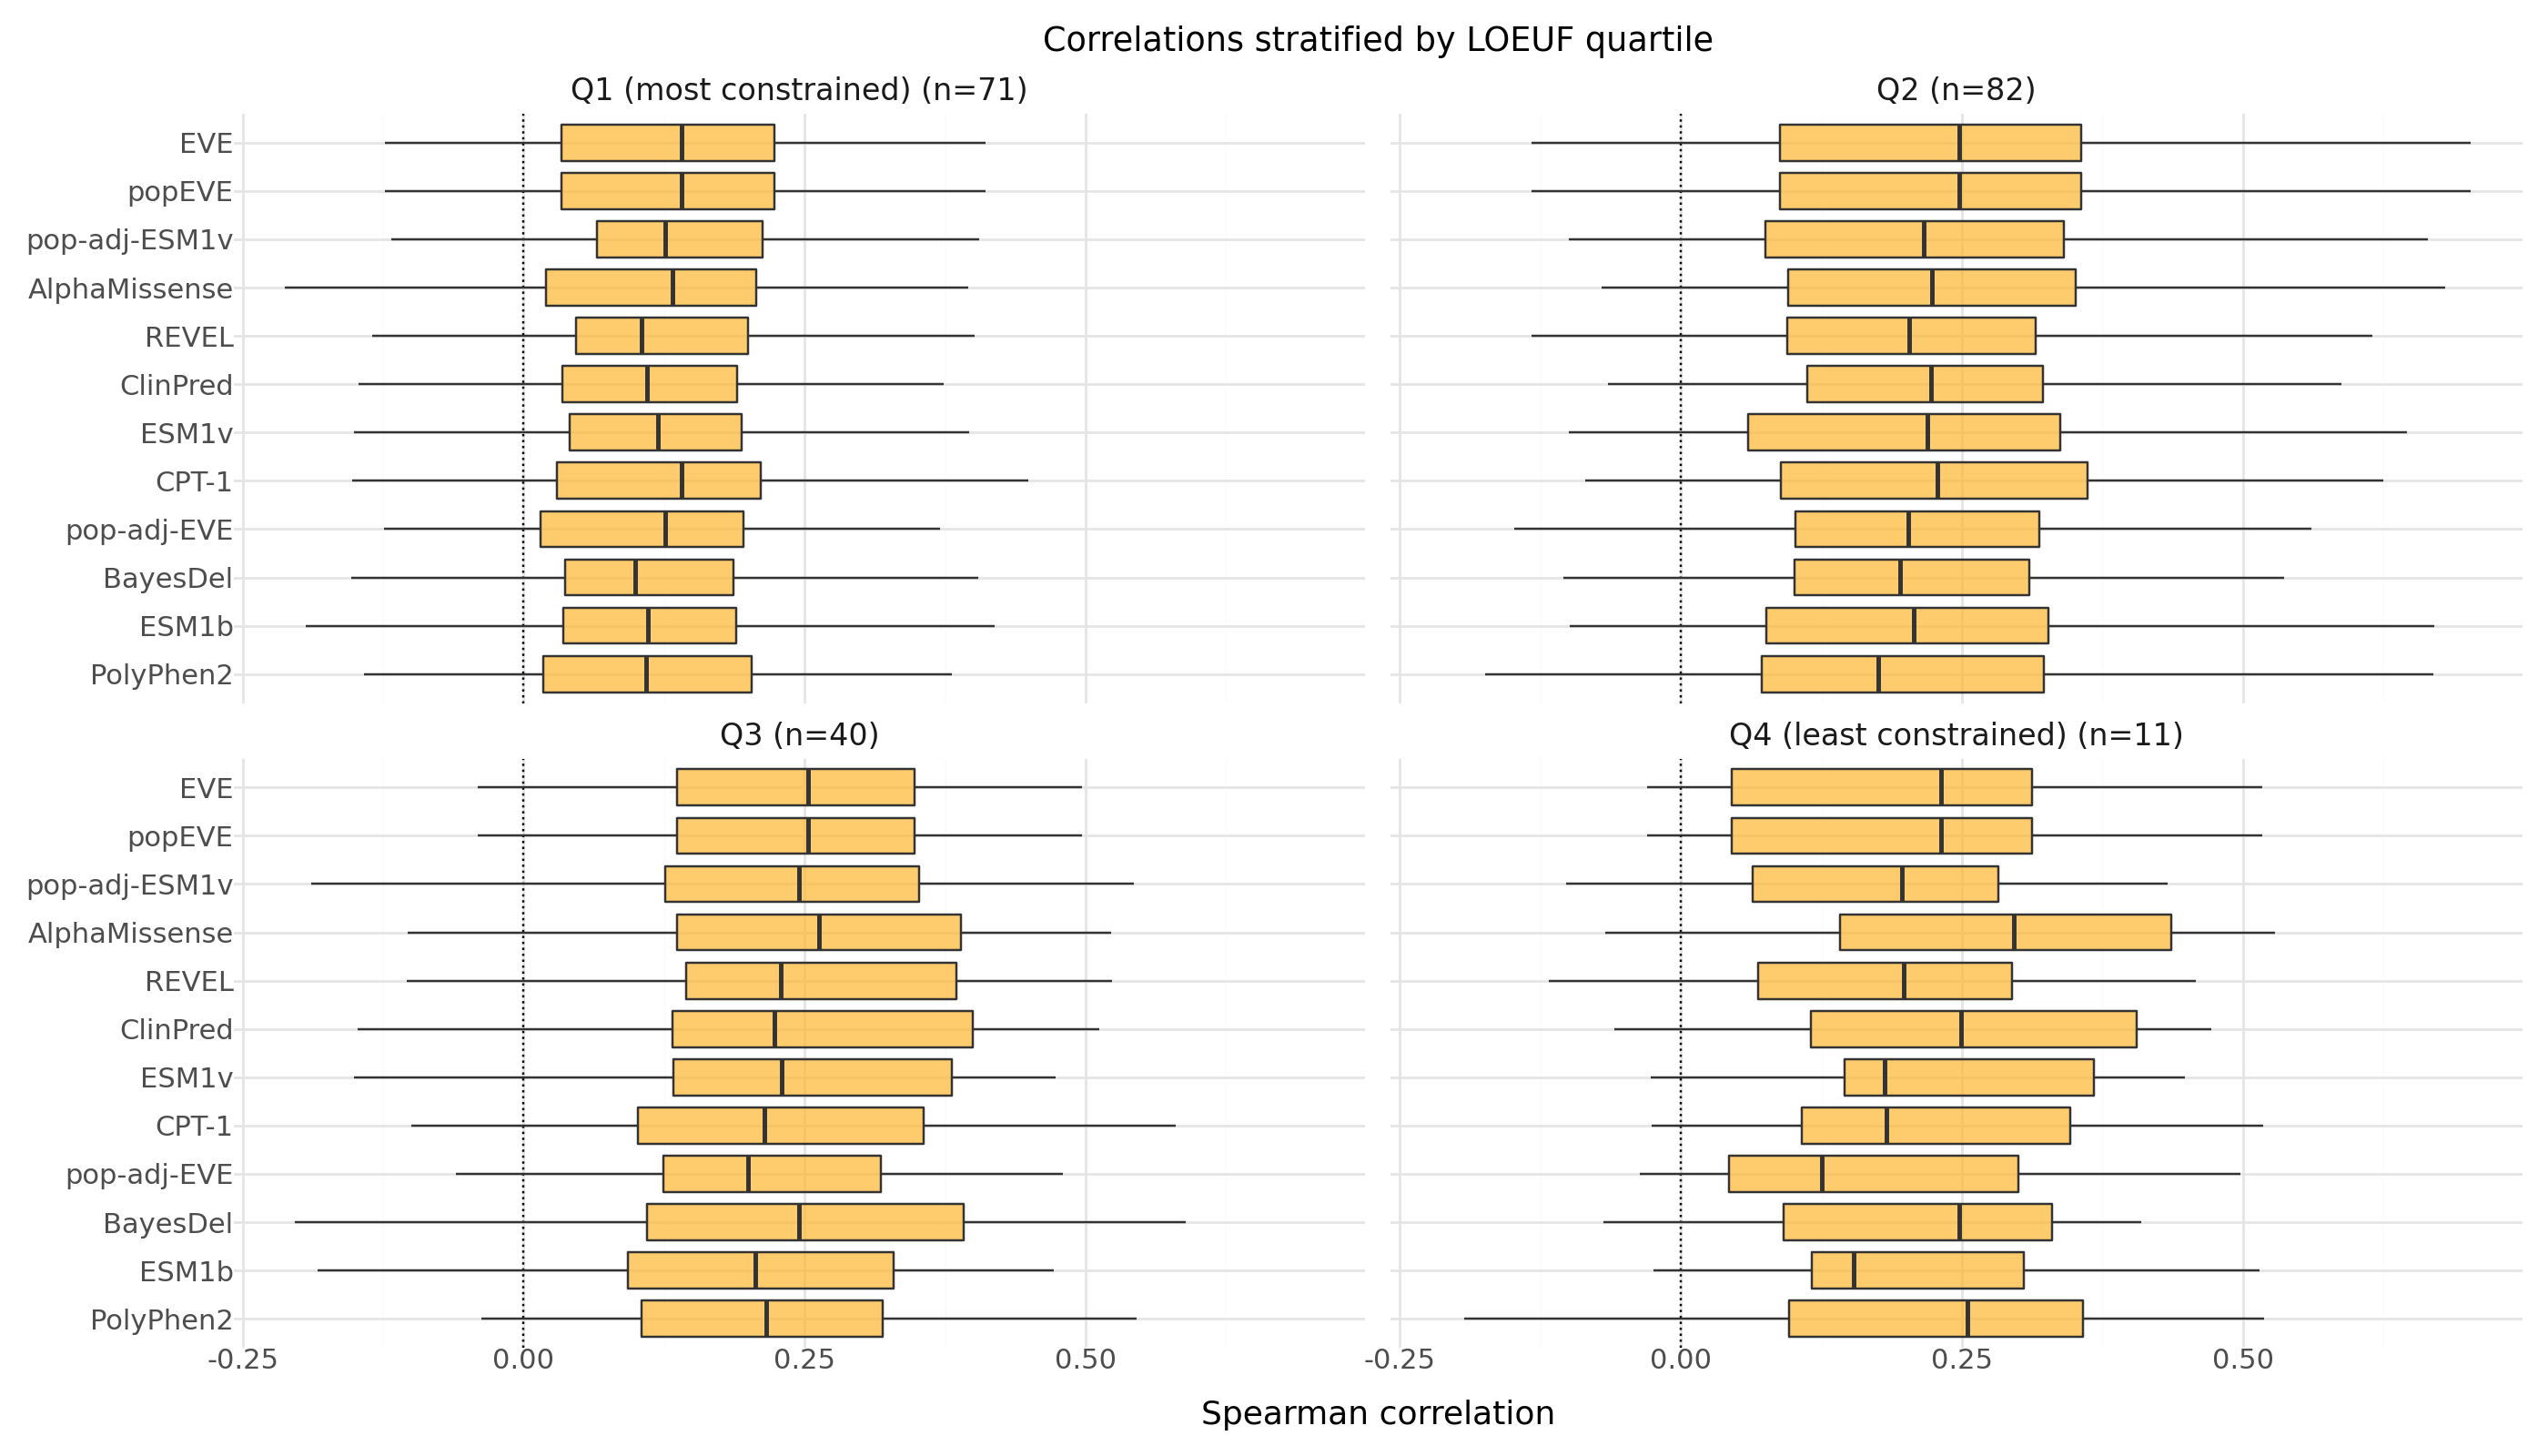

In [16]:
# Create 4 LOEUF bins from the full gnomAD constraint table
loeuf_bins = gnom.with_columns(
    loeuf_bin = pl.col('loeuf').qcut(4, labels=['Q1 (most constrained)', 'Q2', 'Q3', 'Q4 (least constrained)'])
)

# Join LOEUF bins to filt_corr_df
corr_loeuf = (
    filt_corr_df
    .join(loeuf_bins, on='region', how='inner')
    .drop_nans()
)

# Add n= counts to the bin labels
bin_counts = (
    corr_loeuf
    .select(['region', 'phenotype', 'loeuf_bin'])
    .unique(subset=['region', 'phenotype'])
    .group_by('loeuf_bin')
    .len()
)
bin_label_map = {
    row[0]: f"{row[0]} (n={row[1]})" for row in bin_counts.iter_rows()
}
corr_loeuf = corr_loeuf.with_columns(
    pl.col('loeuf_bin').cast(pl.Utf8).replace(bin_label_map).alias('loeuf_bin')
)

plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Order annotations by overall median
corr_loeuf_pl = corr_loeuf.with_columns(
    median_corr_beta = pl.col(plotting_col).median().over("annotation")
)

ordered_labels = (
    corr_loeuf_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

corr_loeuf_pl = corr_loeuf_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

color_dict = dict(corr_loeuf_pl.select("annotation", "color").unique().iter_rows())

(
    ggplot(corr_loeuf_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + facet_wrap("~loeuf_bin", ncol=2)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"Correlations stratified by LOEUF quartile"
    )
    + coord_flip()
    + theme(
        figure_size=(14, corr_loeuf_pl['annotation'].n_unique()/2 + 2),
        legend_position="none",
        axis_text=element_text(size=11),
        axis_title=element_text(size=13),
        strip_text=element_text(size=12),
        plot_background=element_rect(fill="white", color="white"),
    )
)